In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('/content/breast-cancer.csv')

In [3]:
data.head(5)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [4]:
data.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


Important features for Prediction

In [6]:
features = [
    'radius_mean',
    'texture_mean',
    'perimeter_mean',
    'area_mean',
    'compactness_mean',
    'concavity_mean',
    'concave points_mean',
    'radius_worst',
    'perimeter_worst',
    'area_worst',
    'concavity_worst',
    'concave points_worst',
    'diagnosis'
]

data=data[features]

In [7]:
data.head(5)

,radius_mean,texture_mean,perimeter_mean,area_mean,compactness_mean,concavity_mean,concave points_mean,radius_worst,perimeter_worst,area_worst,concavity_worst,concave points_worst,diagnosis
0,17.99,10.38,122.80,1001.0,0.27760,0.3001,0.14710,25.38,184.60,2019.0,0.7119,0.2654,M
1,20.57,17.77,132.90,1326.0,0.07864,0.0869,0.07017,24.99,158.80,1956.0,0.2416,0.1860,M
2,19.69,21.25,130.00,1203.0,0.15990,0.1974,0.12790,23.57,152.50,1709.0,0.4504,0.2430,M
3,11.42,20.38,77.58,386.1,0.28390,0.2414,0.10520,14.91,98.87,567.7,0.6869,0.2575,M
4,20.29,14.34,135.10,1297.0,0.13280,0.1980,0.10430,22.54,152.20,1575.0,0.4000,0.1625,M


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   radius_mean           569 non-null    float64
 1   texture_mean          569 non-null    float64
 2   perimeter_mean        569 non-null    float64
 3   area_mean             569 non-null    float64
 4   compactness_mean      569 non-null    float64
 5   concavity_mean        569 non-null    float64
 6   concave points_mean   569 non-null    float64
 7   radius_worst          569 non-null    float64
 8   perimeter_worst       569 non-null    float64
 9   area_worst            569 non-null    float64
 10  concavity_worst       569 non-null    float64
 11  concave points_worst  569 non-null    float64
 12  diagnosis             569 non-null    object 
dtypes: float64(12), object(1)
memory usage: 57.9+ KB


In [10]:
data['diagnosis'].value_counts()

,count
diagnosis,
B,357
M,212


In [12]:
data['target'] = np.where(data['diagnosis']=='M',1,0)
data.drop('diagnosis',axis=1,inplace=True)

In [13]:
data.head(5)

,radius_mean,texture_mean,perimeter_mean,area_mean,compactness_mean,concavity_mean,concave points_mean,radius_worst,perimeter_worst,area_worst,concavity_worst,concave points_worst,target
0,17.99,10.38,122.80,1001.0,0.27760,0.3001,0.14710,25.38,184.60,2019.0,0.7119,0.2654,1
1,20.57,17.77,132.90,1326.0,0.07864,0.0869,0.07017,24.99,158.80,1956.0,0.2416,0.1860,1
2,19.69,21.25,130.00,1203.0,0.15990,0.1974,0.12790,23.57,152.50,1709.0,0.4504,0.2430,1
3,11.42,20.38,77.58,386.1,0.28390,0.2414,0.10520,14.91,98.87,567.7,0.6869,0.2575,1
4,20.29,14.34,135.10,1297.0,0.13280,0.1980,0.10430,22.54,152.20,1575.0,0.4000,0.1625,1


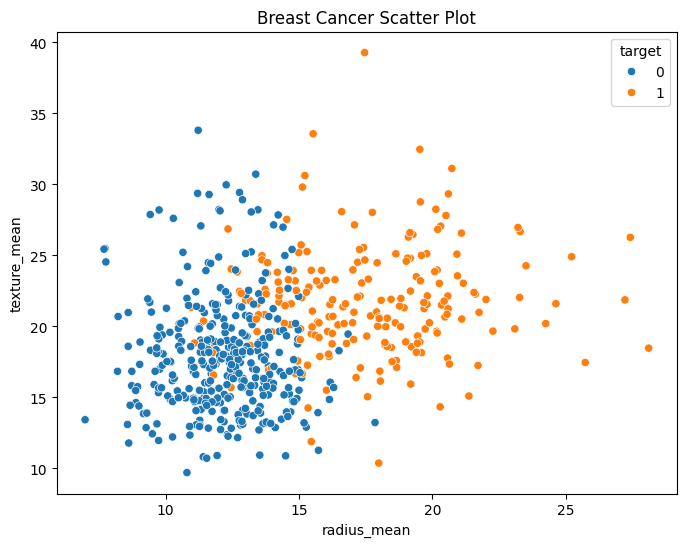

In [26]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='radius_mean',
    y='texture_mean',
    hue='target',
    data=data
)

plt.title("Breast Cancer Scatter Plot")

plt.show()

In [28]:
features = [

    'radius_mean',
    'texture_mean',
    'perimeter_mean',
    'area_mean',
    'compactness_mean',
    'concavity_mean',
    'concave points_mean',
    'radius_worst',
    'perimeter_worst',
    'area_worst',
    'concavity_worst',
    'concave points_worst'

]
x = data[features]
y = data['target']

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

In [30]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [35]:
model = SVC(kernel='rbf',C=1,gamma='scale')
model.fit(x_train,y_train)

SVC(C=1)

In [36]:
y_pred = model.predict(x_test)

In [37]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [38]:
print(accuracy_score(y_test,y_pred))

0.9736842105263158


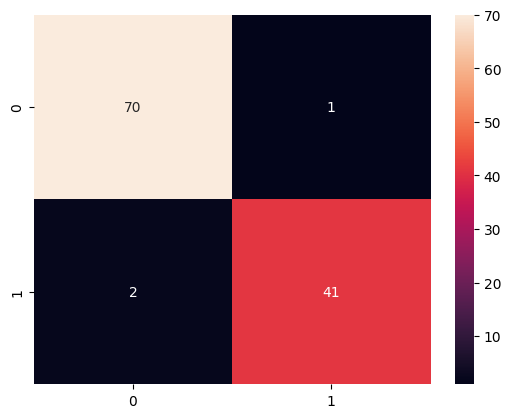

In [39]:
cm = confusion_matrix(y_test,y_pred)

sns.heatmap(cm,annot=True,fmt='d')
plt.show()

In [41]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98        71
           1       0.98      0.95      0.96        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [45]:
sample = X.iloc[0:1]

sample_scaled = scaler.transform(sample)

prediction = model.predict(sample_scaled)

if prediction[0] == 1:
    print("\nPrediction: Malignant Cancer")
else:
    print("\nPrediction: Benign Cancer")


Prediction: Malignant Cancer


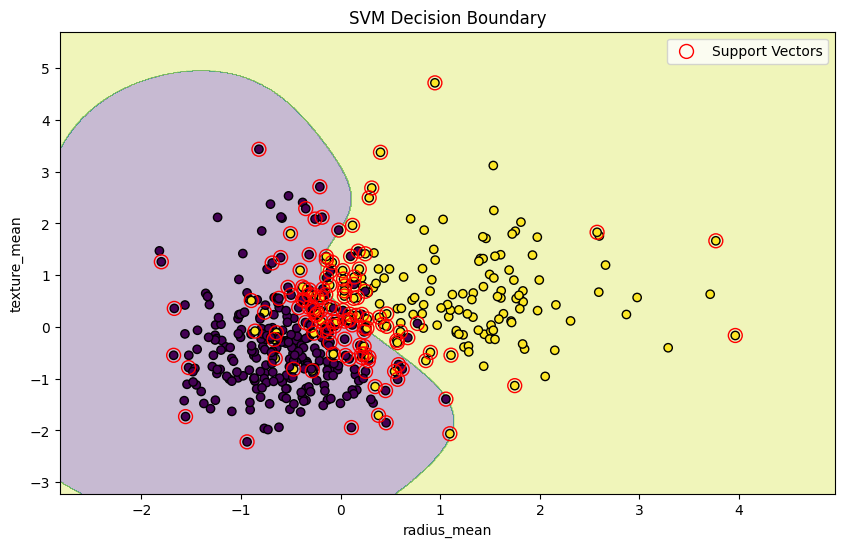

In [47]:


df = pd.read_csv('/content/breast-cancer.csv')

# Remove unnecessary column
if 'id' in df.columns:
    df.drop('id', axis=1, inplace=True)

# Convert labels
df['diagnosis'] = df['diagnosis'].map({
    'B': 0,
    'M': 1
})

# ------------------------------------------------
# USE ONLY 2 FEATURES FOR PLOTTING
# ------------------------------------------------

X = df[['radius_mean', 'texture_mean']]

y = df['diagnosis']

# ------------------------------------------------
# TRAIN TEST SPLIT
# ------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ------------------------------------------------
# FEATURE SCALING
# ------------------------------------------------

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

# ------------------------------------------------
# TRAIN SVM MODEL
# ------------------------------------------------

model = SVC(
    kernel='rbf',
    C=1,
    gamma='scale'
)

model.fit(X_train, y_train)

# ------------------------------------------------
# CREATE MESH GRID
# ------------------------------------------------

x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1

y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.01),
    np.arange(y_min, y_max, 0.01)
)

# ------------------------------------------------
# PREDICT GRID POINTS
# ------------------------------------------------

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])

Z = Z.reshape(xx.shape)

# ------------------------------------------------
# PLOT DECISION BOUNDARY
# ------------------------------------------------

plt.figure(figsize=(10,6))

plt.contourf(xx, yy, Z, alpha=0.3)

# ------------------------------------------------
# PLOT TRAINING DATA
# ------------------------------------------------

scatter = plt.scatter(
    X_train[:, 0],
    X_train[:, 1],
    c=y_train,
    edgecolors='k'
)

# ------------------------------------------------
# PLOT SUPPORT VECTORS ⭐⭐⭐
# ------------------------------------------------

plt.scatter(
    model.support_vectors_[:, 0],
    model.support_vectors_[:, 1],
    s=100,
    facecolors='none',
    edgecolors='red',
    label='Support Vectors'
)

# ------------------------------------------------
# LABELS
# ------------------------------------------------

plt.xlabel("radius_mean")

plt.ylabel("texture_mean")

plt.title("SVM Decision Boundary")

plt.legend()

plt.show()